# Explorative Experiments in Deep Learning

**Advanced Topics in Machine Learning — Assignment 0**

| Field | Value |
|---|---|
| Name | Maryam Zafar |
| Roll Number | 27110054 |

## Task 1: Inner Workings of ResNet-152

### Baseline Setup

We import the libraries needed to build and train the ResNet-152 baseline, including PyTorch, torchvision, and dimensionality-reduction tools used later for activation visualization.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torch.utils.data import DataLoader, random_split

from torchvision import datasets, models, transforms
from torchvision.models import resnet152, ResNet152_Weights, resnet18, ResNet18_Weights
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap


Load a pretrained ResNet-152, freeze all layers except the final fully connected layer which is replaced with a layer for 10 classes, and define ImageNet normalized and train and eval transforms.

In [2]:
model = resnet152(weights = ResNet152_Weights.DEFAULT)
for param in model.parameters():
  param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features,10)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_full = datasets.CIFAR10("./data", train=True, download=True, transform=train_transform)
test_set   = datasets.CIFAR10("./data", train=False, download=True, transform=eval_transform)


n_val = int(len(train_full) * 0.1)
n_train = len(train_full) - n_val
train_set, val_set = random_split(train_full, [n_train, n_val], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_set, batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set, batch_size=64, shuffle=False, num_workers=2)

classes = train_full.classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)





Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 226MB/s]  
100%|██████████| 170M/170M [25:23<00:00, 112kB/s]  


Setting the compute device and define the training/evaluation loop functions used to train the baseline model, tracking loss and accuracy per epoch.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)
        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

criterion = nn.CrossEntropyLoss()


model= model.to(device)
optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-3)

baseline_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
for epoch in range(1, 6):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer)
    val_loss, val_acc = evaluate(model, val_loader)
    baseline_history["train_loss"].append(tr_loss); baseline_history["train_acc"].append(tr_acc)
    baseline_history["val_loss"].append(val_loss); baseline_history["val_acc"].append(val_acc)
    print(f"[baseline] Epoch {epoch}/5 | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

baseline_test_loss, baseline_test_acc = evaluate(model, test_loader)
print(f"Baseline TEST accuracy: {baseline_test_acc:.4f}")

torch.save(model.state_dict(), "resnet152_baseline_head.pth")

Using: cuda
[baseline] Epoch 1/5 | train_loss=0.7156 train_acc=0.7812 | val_loss=0.5226 val_acc=0.8276
[baseline] Epoch 2/5 | train_loss=0.5037 train_acc=0.8326 | val_loss=0.4922 val_acc=0.8334
[baseline] Epoch 3/5 | train_loss=0.4658 train_acc=0.8443 | val_loss=0.4720 val_acc=0.8402
[baseline] Epoch 4/5 | train_loss=0.4408 train_acc=0.8514 | val_loss=0.4444 val_acc=0.8480
[baseline] Epoch 5/5 | train_loss=0.4247 train_acc=0.8568 | val_loss=0.4471 val_acc=0.8474
Baseline TEST accuracy: 0.8474


Plot for the training and validation loss/accuracy curves for the baseline ResNet-152 to assess convergence and overfitting.

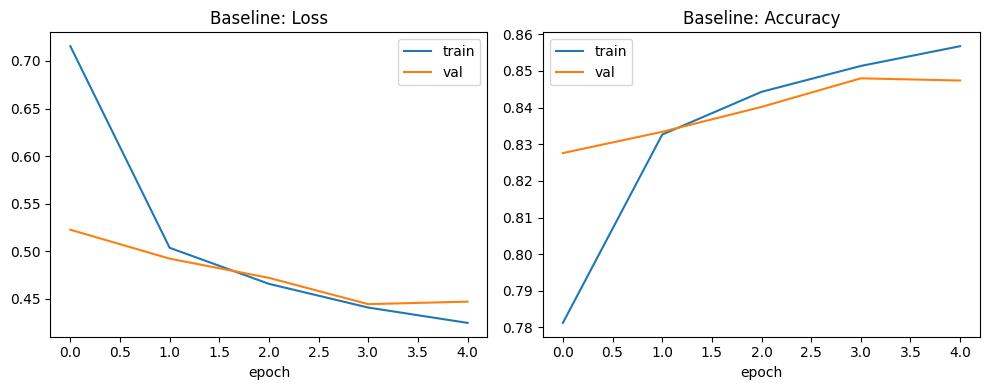

In [4]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(baseline_history["train_loss"], label="train")
plt.plot(baseline_history["val_loss"], label="val")
plt.title("Baseline: Loss"); plt.xlabel("epoch"); plt.legend()

plt.subplot(1,2,2)
plt.plot(baseline_history["train_acc"], label="train")
plt.plot(baseline_history["val_acc"], label="val")
plt.title("Baseline: Accuracy"); plt.xlabel("epoch"); plt.legend()
plt.tight_layout()
plt.savefig("part1_curves.png", dpi=150)
plt.show()

### Residual Connections in Practice

To study the role of skip connections, we override the forward pass of ResNet's Bottleneck blocks to disable residual addition, then retrain an identical model and compare it against the baseline.

In [ ]:
from torchvision.models.resnet import Bottleneck

def _no_residual_forward(self, x):
    out = self.conv1(x); out = self.bn1(out); out = self.relu(out)
    out = self.conv2(out); out = self.bn2(out); out = self.relu(out)
    out = self.conv3(out); out = self.bn3(out)
    out = self.relu(out)
    return out

def disable_skip_connections(model, block_ids):
    for layer_name, idx in block_ids:
        block = getattr(model, layer_name)[idx]
        assert isinstance(block, Bottleneck)
        block.forward = _no_residual_forward.__get__(block, Bottleneck)

model_noskip = resnet152(weights=ResNet152_Weights.DEFAULT)
for param in model_noskip.parameters():
    param.requires_grad = False
model_noskip.fc = nn.Linear(model_noskip.fc.in_features, 10)
model_noskip = model_noskip.to(device)

BLOCKS_TO_ABLATE = [("layer2", 0), ("layer3", 3), ("layer4", 1)]
disable_skip_connections(model_noskip, BLOCKS_TO_ABLATE)



optimizer_noskip = optim.Adam([p for p in model_noskip.parameters() if p.requires_grad], lr=1e-3)

noskip_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
for epoch in range(1, 6):
    tr_loss, tr_acc = train_one_epoch(model_noskip, train_loader, optimizer_noskip)
    val_loss, val_acc = evaluate(model_noskip, val_loader)
    noskip_history["train_loss"].append(tr_loss); noskip_history["train_acc"].append(tr_acc)
    noskip_history["val_loss"].append(val_loss); noskip_history["val_acc"].append(val_acc)
    print(f"[no-skip] Epoch {epoch}/5 | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

noskip_test_loss, noskip_test_acc = evaluate(model_noskip, test_loader)
print(f"No-skip TEST accuracy: {noskip_test_acc:.4f}")

[no-skip] Epoch 1/5 | train_loss=2.2966 train_acc=0.1182 | val_loss=2.6196 val_acc=0.1190
[no-skip] Epoch 2/5 | train_loss=2.2901 train_acc=0.1307 | val_loss=2.3958 val_acc=0.1322
[no-skip] Epoch 3/5 | train_loss=2.2862 train_acc=0.1352 | val_loss=2.6327 val_acc=0.1294
[no-skip] Epoch 4/5 | train_loss=2.2844 train_acc=0.1361 | val_loss=2.4453 val_acc=0.1260
[no-skip] Epoch 5/5 | train_loss=2.2818 train_acc=0.1376 | val_loss=2.6929 val_acc=0.1330
No-skip TEST accuracy: 0.1422


We compare validation loss and accuracy between the baseline and the no-skip-connection variant.

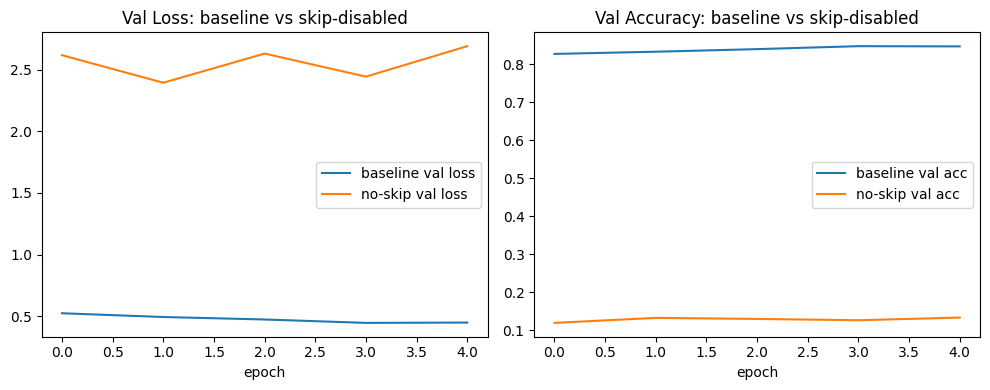

Baseline test acc: 0.8474 | No-skip test acc: 0.1422


In [6]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(baseline_history["val_loss"], label="baseline val loss")
plt.plot(noskip_history["val_loss"], label="no-skip val loss")
plt.title("Val Loss: baseline vs skip-disabled"); plt.xlabel("epoch"); plt.legend()

plt.subplot(1,2,2)
plt.plot(baseline_history["val_acc"], label="baseline val acc")
plt.plot(noskip_history["val_acc"], label="no-skip val acc")
plt.title("Val Accuracy: baseline vs skip-disabled"); plt.xlabel("epoch"); plt.legend()
plt.tight_layout()
plt.savefig("part2_comparison.png", dpi=150)
plt.show()

print(f"Baseline test acc: {baseline_test_acc:.4f} | No-skip test acc: {noskip_test_acc:.4f}")

**Results:** the no-skip model shows a substantial accuracy gap versus baseline, confirming that residual connections are critical for training very deep networks like ResNet-152.

Register forward hooks on early, middle, and late layers to extract intermediate activations, which we visualize with t-SNE and UMAP to see how representations evolve through the network.

In [ ]:
!pip install umap-learn -q

activations = {}
def get_hook(name):
    def hook(module, inp, out):
        pooled = out.mean(dim=[2, 3])
        activations.setdefault(name, []).append(pooled.detach().cpu())
    return hook

STAGES = {"early": "layer1", "middle": "layer2", "late": "layer4"}
handles = []
for stage_name, layer_name in STAGES.items():
    layer = dict(model.named_modules())[layer_name]
    handles.append(layer.register_forward_hook(get_hook(layer_name)))

model.eval()
all_labels = []
with torch.no_grad():
    for i, (x, y) in enumerate(val_loader):
        if i >= 15:
            break
        model(x.to(device))
        all_labels.append(y)
all_labels = torch.cat(all_labels).numpy()

for h in handles:
    h.remove()

features_by_stage = {
    stage_name: torch.cat(activations[layer_name]).numpy()
    for stage_name, layer_name in STAGES.items()
}

We reduce the extracted activations to 2D with t-SNE and plot them colored by class, for each stage.

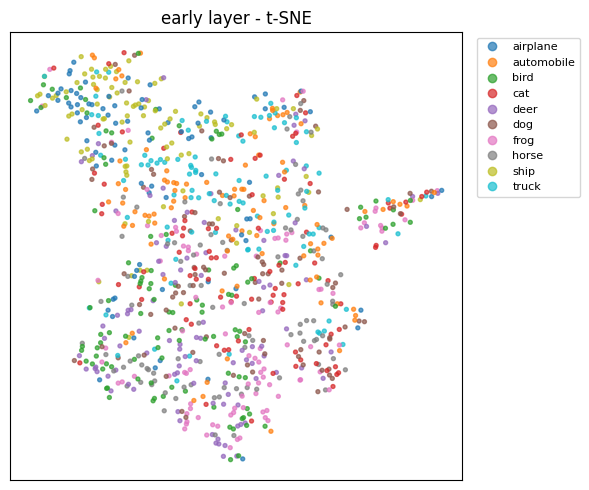

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


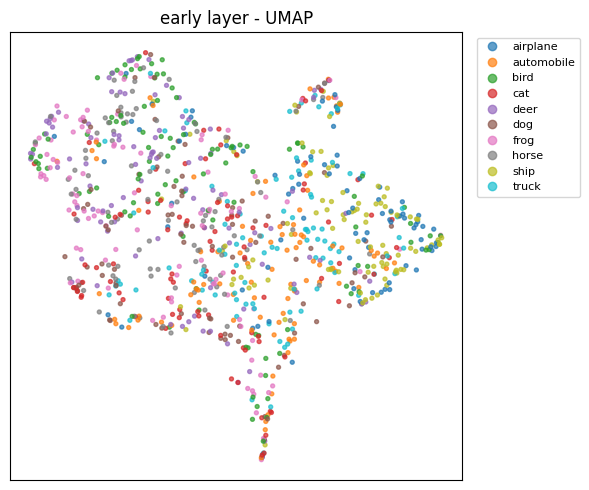

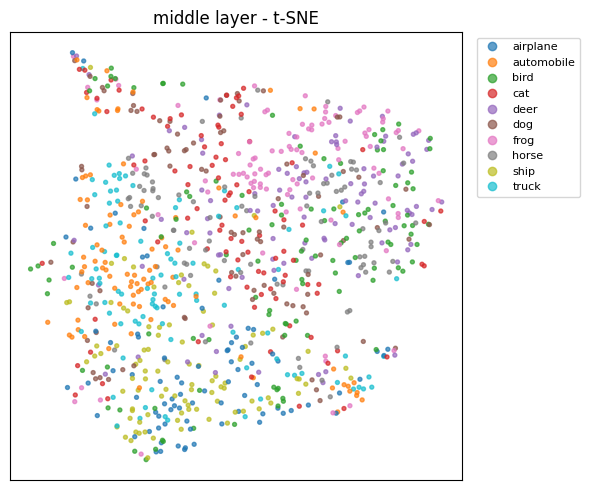

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


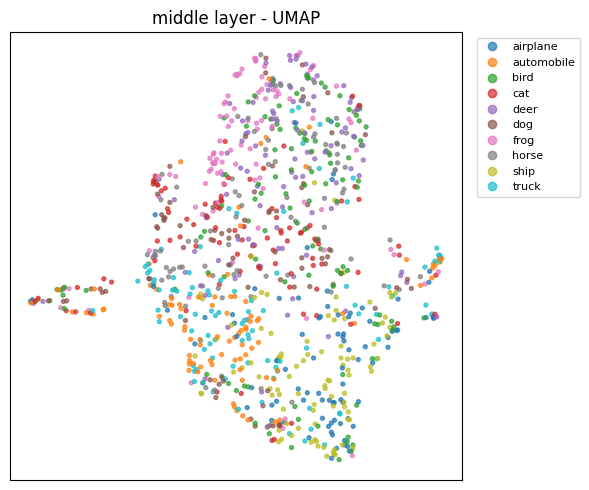

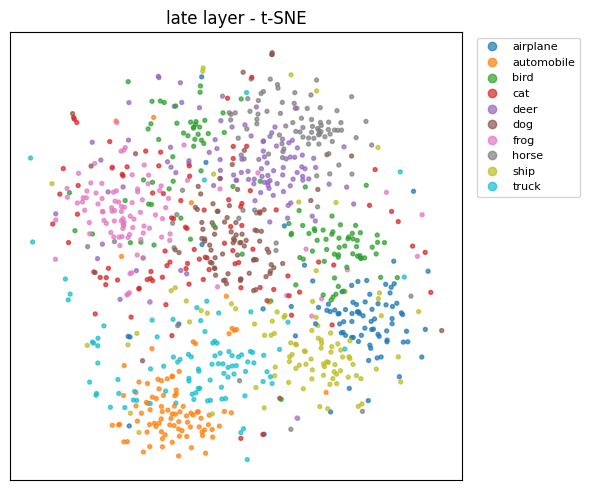

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


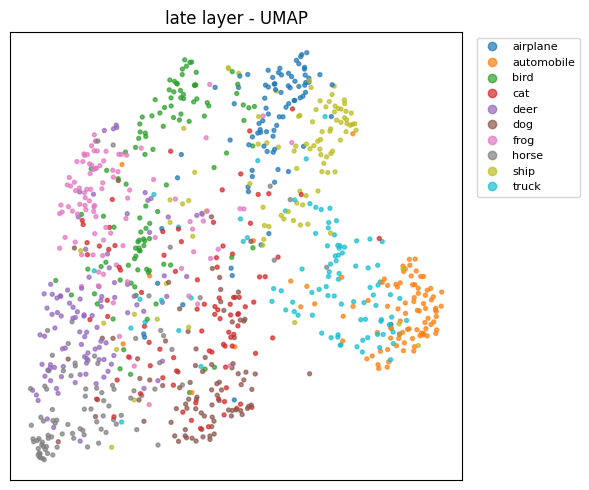

In [ ]:
from sklearn.manifold import TSNE
import umap

def plot_embedding(emb, labels, title):
    plt.figure(figsize=(6,5))
    scatter = plt.scatter(emb[:,0], emb[:,1], c=labels, cmap="tab10", s=8, alpha=0.7)
    handles_, _ = scatter.legend_elements()
    plt.legend(handles_, classes, bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8)
    plt.title(title); plt.xticks([]); plt.yticks([]); plt.tight_layout()
    plt.savefig(title.replace(" ","_").replace("(","").replace(")","") + ".png", dpi=150)
    plt.show()

for stage_name, feats in features_by_stage.items():
    tsne_emb = TSNE(n_components=2, random_state=42, init="pca").fit_transform(feats)
    plot_embedding(tsne_emb, all_labels, f"{stage_name} layer - t-SNE")

    umap_emb = umap.UMAP(n_components=2, random_state=42).fit_transform(feats)
    plot_embedding(umap_emb, all_labels, f"{stage_name} layer - UMAP")

### Transfer Learning on STL-10

We load the STL-10 dataset, used to evaluate transfer learning performance of pretrained vs. randomly-initialized ResNet-152 under different fine-tuning strategies.

In [9]:
stl_train = datasets.STL10("./data", split="train", download=True, transform=train_transform)
stl_test  = datasets.STL10("./data", split="test", download=True, transform=eval_transform)

n_val_stl = int(len(stl_train) * 0.1)
n_train_stl = len(stl_train) - n_val_stl
stl_train_set, stl_val_set = random_split(stl_train, [n_train_stl, n_val_stl], generator=torch.Generator().manual_seed(42))

stl_train_loader = DataLoader(stl_train_set, batch_size=32, shuffle=True, num_workers=2)
stl_val_loader   = DataLoader(stl_val_set, batch_size=32, shuffle=False, num_workers=2)
stl_test_loader  = DataLoader(stl_test, batch_size=32, shuffle=False, num_workers=2)
stl_classes = stl_train.classes
print("STL-10 classes:", stl_classes)

100%|██████████| 2.64G/2.64G [16:04<00:00, 2.74MB/s] 


STL-10 classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


Build four model variants for the transfer learning grid: pretrained vs. random initialization, crossed with fine-tuning only the final block vs. the full network.

In [ ]:
from torchvision.models import resnet152, ResNet152_Weights
import torch.nn as nn

def build_transfer_model(pretrained, mode):
    weights = ResNet152_Weights.DEFAULT if pretrained else None
    m = resnet152(weights=weights)
    for param in m.parameters():
        param.requires_grad = False
    m.fc = nn.Linear(m.fc.in_features, len(stl_classes))

    if mode == "final_block":
        for param in m.layer4.parameters():
            param.requires_grad = True
    elif mode == "full":
        for param in m.parameters():
            param.requires_grad = True
    return m.to(device)

configs = [
    {"name": "pretrained_final_block", "pretrained": True,  "mode": "final_block"},
    {"name": "pretrained_full",        "pretrained": True,  "mode": "full"},
    {"name": "random_final_block",     "pretrained": False, "mode": "final_block"},
    {"name": "random_full",            "pretrained": False, "mode": "full"},
]

transfer_results = {}
for cfg in configs:
    print(f"\n=== {cfg['name']} ===")
    m = build_transfer_model(cfg["pretrained"], cfg["mode"])
    lr = 1e-4 if cfg["mode"] == "full" else 1e-3   # full fine-tune needs a smaller LR
    opt = optim.Adam([p for p in m.parameters() if p.requires_grad], lr=lr)

    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, 6):
        tr_loss, tr_acc = train_one_epoch(m, stl_train_loader, opt)
        val_loss, val_acc = evaluate(m, stl_val_loader)
        hist["train_loss"].append(tr_loss); hist["train_acc"].append(tr_acc)
        hist["val_loss"].append(val_loss); hist["val_acc"].append(val_acc)
        print(f"[{cfg['name']}] Epoch {epoch}/5 | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    test_loss, test_acc = evaluate(m, stl_test_loader)
    print(f"{cfg['name']}: TEST acc={test_acc:.4f}")
    transfer_results[cfg["name"]] = {"history": hist, "test_acc": test_acc}


import pandas as pd
summary = pd.DataFrame({
    "config": list(transfer_results.keys()),
    "test_acc": [transfer_results[k]["test_acc"] for k in transfer_results],
    "final_val_acc": [transfer_results[k]["history"]["val_acc"][-1] for k in transfer_results],
})
print(summary.sort_values("test_acc", ascending=False))


=== pretrained_final_block ===
[pretrained_final_block] Epoch 1/5 | val_loss=0.1310 val_acc=0.9560
[pretrained_final_block] Epoch 2/5 | val_loss=0.0730 val_acc=0.9740
[pretrained_final_block] Epoch 3/5 | val_loss=0.0753 val_acc=0.9720
[pretrained_final_block] Epoch 4/5 | val_loss=0.0685 val_acc=0.9760
[pretrained_final_block] Epoch 5/5 | val_loss=0.1138 val_acc=0.9740
pretrained_final_block: TEST acc=0.9775

=== pretrained_full ===
[pretrained_full] Epoch 1/5 | val_loss=0.0826 val_acc=0.9680
[pretrained_full] Epoch 2/5 | val_loss=0.0600 val_acc=0.9760
[pretrained_full] Epoch 3/5 | val_loss=0.0642 val_acc=0.9780
[pretrained_full] Epoch 4/5 | val_loss=0.0834 val_acc=0.9760
[pretrained_full] Epoch 5/5 | val_loss=0.1187 val_acc=0.9700
pretrained_full: TEST acc=0.9732

=== random_final_block ===
[random_final_block] Epoch 1/5 | val_loss=3.3724 val_acc=0.1400
[random_final_block] Epoch 2/5 | val_loss=2.1060 val_acc=0.2140
[random_final_block] Epoch 3/5 | val_loss=2.0920 val_acc=0.2520
[rand

We identify the most commonly confused class pairs for the trained model to surface systematic errors.

Most confused CIFAR-10 pairs: [(('dog', 'cat'), 156), (('automobile', 'truck'), 81), (('frog', 'cat'), 64), (('horse', 'deer'), 61), (('cat', 'dog'), 59)]
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s] 


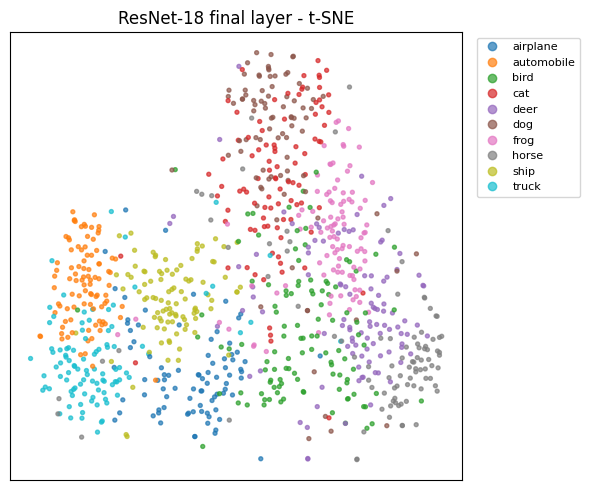

In [ ]:
from collections import Counter

def confused_pairs(model, loader, class_names, top_k=5):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in loader:
            preds.append(model(x.to(device)).argmax(1).cpu())
            targets.append(y)
    preds, targets = torch.cat(preds).numpy(), torch.cat(targets).numpy()
    mistakes = Counter((class_names[t], class_names[p]) for t, p in zip(targets, preds) if t != p)
    return mistakes.most_common(top_k)

print("Most confused CIFAR-10 pairs:", confused_pairs(model, test_loader, classes))


def hook18(module, inp, out):
    acts18.setdefault("layer4", []).append(out.mean(dim=[2, 3]).detach().cpu())

model18 = resnet18(weights=ResNet18_Weights.DEFAULT)
for param in model18.parameters():
    param.requires_grad = False
model18.fc = nn.Linear(model18.fc.in_features, 10)
model18 = model18.to(device)

acts18 = {}
h = dict(model18.named_modules())["layer4"].register_forward_hook(hook18)

model18.eval()
labels18 = []
with torch.no_grad():
    for i, (x, y) in enumerate(val_loader):
        if i >= 15:
            break
        model18(x.to(device))
        labels18.append(y)
h.remove()

labels18 = torch.cat(labels18).numpy()
feats18 = torch.cat(acts18["layer4"]).numpy()
emb18 = TSNE(n_components=2, random_state=42, init="pca").fit_transform(feats18)
plot_embedding(emb18, labels18, "ResNet-18 final layer - t-SNE")


This concludes Task 1 (ResNet-152 internals, residual-connection ablation, and transfer learning).

## Task 2: Vision Transformers (ViT)

This section covers ViT image classification, CLS-token attention visualization, per-head attention analysis, patch-masking robustness, and a comparison of CLS-token vs. mean-pooled linear probes.

We load a pretrained ViT (google/vit-base-patch16-224) model and processor from HuggingFace Transformers for image classification.

In [15]:
!pip install transformers -q

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import ViTForImageClassification, ViTImageProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)
vit_model = ViTForImageClassification.from_pretrained(model_name).to(device)
vit_model.eval()

print("Patch size:", vit_model.config.patch_size)
print("Image size:", vit_model.config.image_size)
print("Num labels:", vit_model.config.num_labels)

Device: cuda


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Patch size: 16
Image size: 224
Num labels: 1000


We select a few sample CIFAR-10 images and run ViT classification on them as a qualitative sanity check.

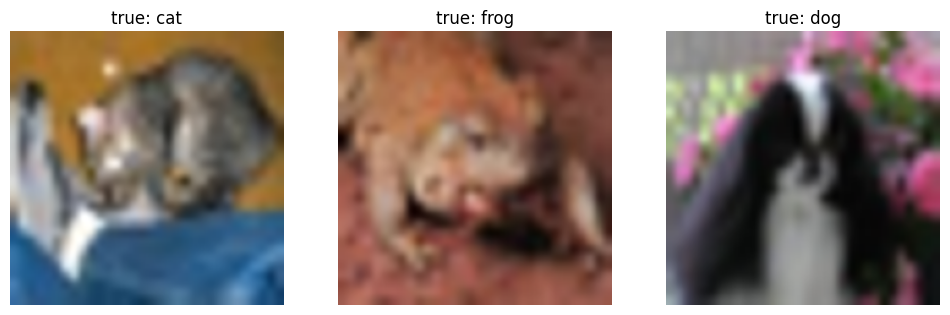

Image 0 (true CIFAR-10 label: cat) -> ViT top-1 prediction: tabby, tabby cat
Image 1 (true CIFAR-10 label: frog) -> ViT top-1 prediction: frilled lizard, Chlamydosaurus kingi
Image 2 (true CIFAR-10 label: dog) -> ViT top-1 prediction: Japanese spaniel


In [16]:
from torchvision import datasets
import torchvision.transforms as T

raw_cifar_test = datasets.CIFAR10("./data", train=False, download=True)
sample_indices = [0, 5, 42]
images = [raw_cifar_test[i][0].resize((224,224)) for i in sample_indices]
true_labels = [raw_cifar_test.classes[raw_cifar_test[i][1]] for i in sample_indices]

fig, axes = plt.subplots(1, len(images), figsize=(12,4))
for ax, img, label in zip(axes, images, true_labels):
    ax.imshow(img); ax.set_title(f"true: {label}"); ax.axis("off")
plt.show()


inputs = processor(images=images, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = vit_model(**inputs)
    logits = outputs.logits

top1 = logits.argmax(-1)
for i, idx in enumerate(top1):
    predicted_label = vit_model.config.id2label[idx.item()]
    print(f"Image {i} (true CIFAR-10 label: {true_labels[i]}) -> ViT top-1 prediction: {predicted_label}")

We extract the CLS token's attention over image patches in the final transformer layer, visualizing what the model attends to when classifying.

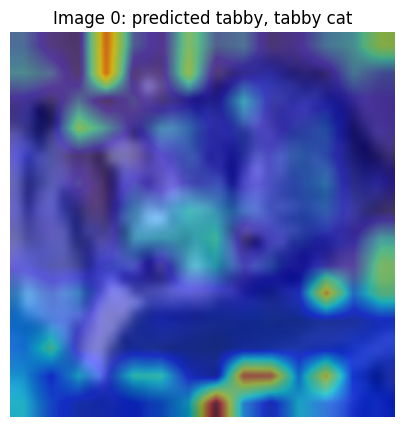

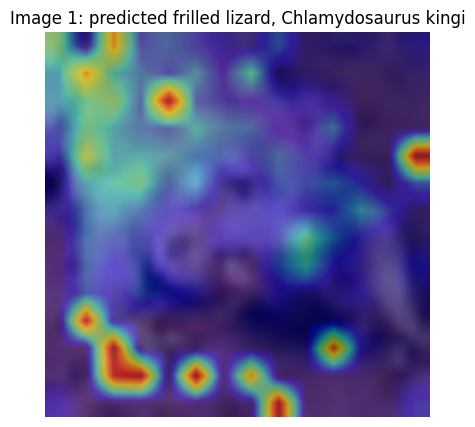

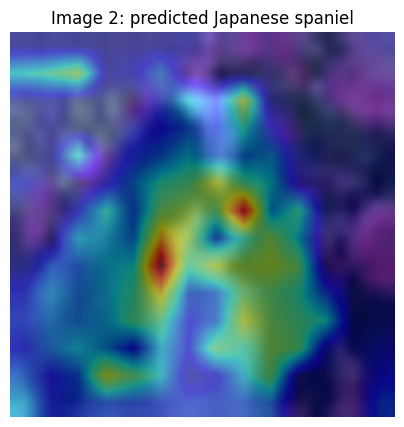

In [ ]:
vit_model.config._attn_implementation = "eager"
vit_model.config.output_attentions = True

def get_cls_attention_map(model, processor, image, device):
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    final_layer_attn = outputs.attentions[-1]
    avg_heads = final_layer_attn.mean(dim=1)

    cls_to_patches = avg_heads[0, 0, 1:]

    num_patches = cls_to_patches.shape[0]
    grid_size = int(num_patches ** 0.5)
    attn_map = cls_to_patches.reshape(grid_size, grid_size).cpu().numpy()
    pred_class = outputs.logits.argmax(-1).item()
    return attn_map, model.config.id2label[pred_class]

def overlay_attention(image, attn_map, title=""):
    img_np = np.array(image.resize((224,224))) / 255.0
    attn_resized = np.array(Image.fromarray((attn_map / attn_map.max() * 255).astype(np.uint8)).resize((224,224), Image.BILINEAR)) / 255.0

    plt.figure(figsize=(5,5))
    plt.imshow(img_np)
    plt.imshow(attn_resized, cmap="jet", alpha=0.5)
    plt.title(title); plt.axis("off")
    plt.savefig(title.replace(" ","_").replace(":","") + ".png", dpi=150, bbox_inches="tight")
    plt.show()

for i, img in enumerate(images):
    attn_map, pred_label = get_cls_attention_map(vit_model, processor, img, device)
    overlay_attention(img, attn_map, title=f"Image {i}: predicted {pred_label}")

We break down attention per individual head in the final layer, to see whether different heads specialize in different spatial patterns.

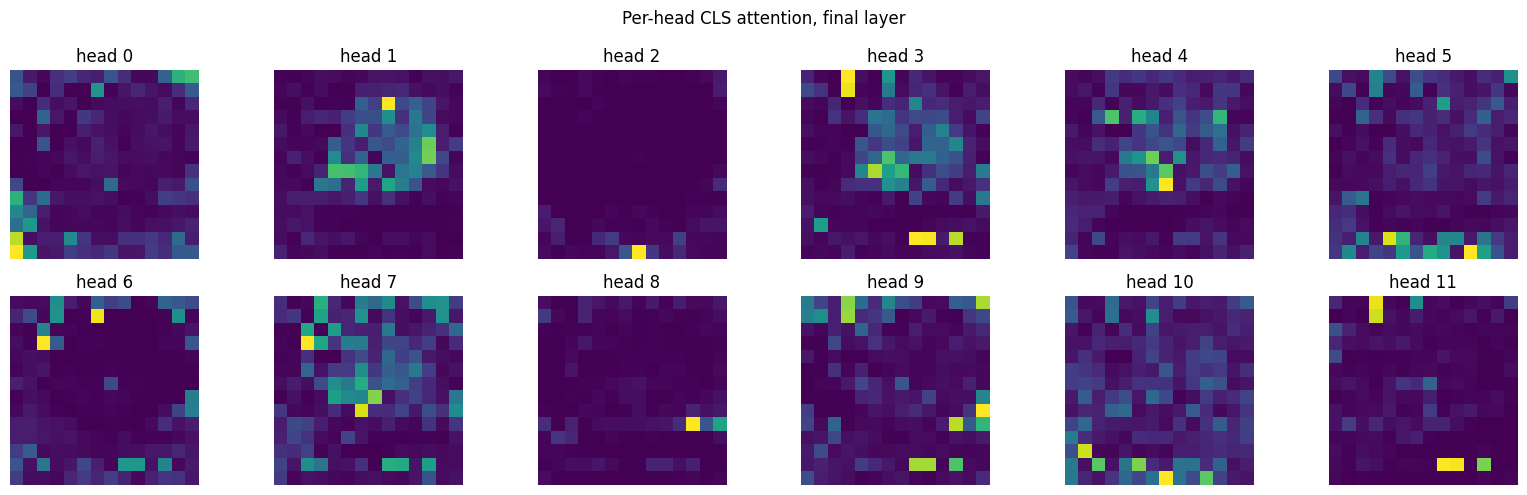

In [ ]:
def get_per_head_attention(model, processor, image, device):
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    final_layer_attn = outputs.attentions[-1][0]
    num_heads = final_layer_attn.shape[0]
    grid_size = int((final_layer_attn.shape[-1] - 1) ** 0.5)

    fig, axes = plt.subplots(2, num_heads // 2, figsize=(16, 5))
    for h in range(num_heads):
        cls_to_patches = final_layer_attn[h, 0, 1:].reshape(grid_size, grid_size).cpu().numpy()
        ax = axes[h // (num_heads//2), h % (num_heads//2)]
        ax.imshow(cls_to_patches, cmap="viridis")
        ax.set_title(f"head {h}"); ax.axis("off")
    plt.suptitle("Per-head CLS attention, final layer")
    plt.tight_layout()
    plt.savefig("per_head_attention.png", dpi=150)
    plt.show()

get_per_head_attention(vit_model, processor, images[0], device)

We test ViT's robustness to occlusion by masking a fraction of image patches (randomly or in a structured/center pattern) and observing the effect on predictions.

mask_frac=0.0, mode=random: accuracy=0.230
mask_frac=0.15, mode=random: accuracy=0.220
mask_frac=0.15, mode=center: accuracy=0.200
mask_frac=0.3, mode=random: accuracy=0.180
mask_frac=0.3, mode=center: accuracy=0.090
mask_frac=0.5, mode=random: accuracy=0.150
mask_frac=0.5, mode=center: accuracy=0.030
mask_frac=0.7, mode=random: accuracy=0.090
mask_frac=0.7, mode=center: accuracy=0.010


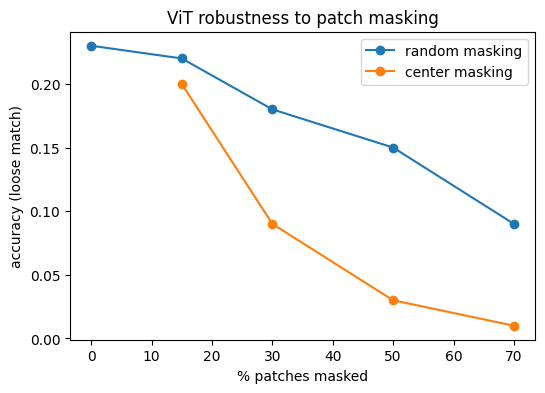

In [ ]:
import random

def mask_image_patches(pil_image, patch_size=16, grid_size=14, frac=0.3, mode="random"):
    img = np.array(pil_image.resize((224,224))).copy()
    total_patches = grid_size * grid_size
    n_mask = int(total_patches * frac)

    if mode == "random":
        mask_idx = random.sample(range(total_patches), n_mask)
    elif mode == "center":
        center = grid_size // 2
        coords = [(r,c) for r in range(grid_size) for c in range(grid_size)]
        coords.sort(key=lambda rc: (rc[0]-center)**2 + (rc[1]-center)**2)
        mask_idx = [r*grid_size+c for r,c in coords[:n_mask]]

    for idx in mask_idx:
        r, c = idx // grid_size, idx % grid_size
        img[r*patch_size:(r+1)*patch_size, c*patch_size:(c+1)*patch_size] = 0

    return Image.fromarray(img)

@torch.no_grad()
def evaluate_vit_accuracy(model, processor, dataset, indices, mask_frac=0.0, mask_mode="random"):
    correct, total = 0, 0
    for i in indices:
        img, label_idx = dataset[i]
        img = img.resize((224,224))
        if mask_frac > 0:
            img = mask_image_patches(img, frac=mask_frac, mode=mask_mode)
        inputs = processor(images=img, return_tensors="pt").to(device)
        pred = model(**inputs).logits.argmax(-1).item()
        pred_label = model.config.id2label[pred].lower()
        true_label = dataset.classes[label_idx].lower()
        correct += int(true_label in pred_label)
        total += 1
    return correct / total

test_indices = list(range(100))

results = {}
for mask_frac in [0.0, 0.15, 0.3, 0.5, 0.7]:
    for mode in (["random"] if mask_frac == 0.0 else ["random", "center"]):
        acc = evaluate_vit_accuracy(vit_model, processor, raw_cifar_test, test_indices, mask_frac, mode)
        results[f"{mask_frac}_{mode}"] = acc
        print(f"mask_frac={mask_frac}, mode={mode}: accuracy={acc:.3f}")



random_accs = [results[f"{f}_random"] for f in [0.0, 0.15, 0.3, 0.5, 0.7]]
center_accs = [results.get(f"{f}_center") for f in [0.0, 0.15, 0.3, 0.5, 0.7]]  # None for f=0.0

plt.figure(figsize=(6,4))
plt.plot([0,15,30,50,70], random_accs, marker="o", label="random masking")
plt.plot([15,30,50,70], center_accs[1:], marker="o", label="center masking")
plt.xlabel("% patches masked"); plt.ylabel("accuracy (loose match)")
plt.title("ViT robustness to patch masking")
plt.legend()
plt.savefig("patch_masking_curve.png", dpi=150)
plt.show()

We compare linear-probe classification accuracy using the CLS token vs. mean-pooled patch embeddings as features, to see which representation is more linearly separable.

In [ ]:
from sklearn.linear_model import LogisticRegression

@torch.no_grad()
def extract_vit_features(model, processor, dataset, indices):
    cls_feats, mean_feats, labels = [], [], []
    for i in indices:
        img, label_idx = dataset[i]
        img = img.resize((224,224))
        inputs = processor(images=img, return_tensors="pt").to(device)
        out = model.vit(**inputs, output_hidden_states=False)
        last_hidden = out.last_hidden_state[0]

        cls_feats.append(last_hidden[0].cpu().numpy())
        mean_feats.append(last_hidden[1:].mean(0).cpu().numpy())
        labels.append(label_idx)
    return np.array(cls_feats), np.array(mean_feats), np.array(labels)

train_indices = list(range(500))
test_indices_probe = list(range(500, 700))

raw_cifar_train = datasets.CIFAR10("./data", train=True, download=True)

cls_train, mean_train, y_train = extract_vit_features(vit_model, processor, raw_cifar_train, train_indices)
cls_test, mean_test, y_test = extract_vit_features(vit_model, processor, raw_cifar_test, test_indices_probe)

clf_cls = LogisticRegression(max_iter=1000).fit(cls_train, y_train)
clf_mean = LogisticRegression(max_iter=1000).fit(mean_train, y_train)

acc_cls = clf_cls.score(cls_test, y_test)
acc_mean = clf_mean.score(mean_test, y_test)

print(f"Linear probe accuracy — CLS token:  {acc_cls:.4f}")
print(f"Linear probe accuracy — mean-pooled: {acc_mean:.4f}")

Linear probe accuracy — CLS token:  0.9750
Linear probe accuracy — mean-pooled: 0.9850


This concludes Task 2 (ViT classification, attention visualization, patch-masking robustness, and CLS-token vs. mean-pooled probes).

## Task 3: CLIP — Zero-Shot Classification and Cross-Modal Alignment

We explore OpenAI's CLIP model, which jointly embeds images and text into a shared space. We evaluate zero-shot classification accuracy on STL-10 under different prompting strategies, visualize the image/text modality gap, and test whether Procrustes alignment closes that gap.

We install and load CLIP (ViT-B/32), which we use for zero-shot classification and cross-modal embedding analysis below.

In [21]:
!pip install ftfy regex tqdm -q
!pip install git+https://github.com/openai/CLIP.git -q

import torch
import clip
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import STL10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()
print("CLIP loaded on", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 184MiB/s]


CLIP loaded on cuda


We load STL-10 test data preprocessed for CLIP and inspect the class names used for prompt construction.

In [22]:
stl_test = STL10("./data", split="test", download=True, transform=clip_preprocess)
class_names = stl_test.classes
print("STL-10 classes:", class_names)

STL-10 classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


We evaluate CLIP's zero-shot classification accuracy using different text-prompt templates.

In [ ]:
from torch.utils.data import DataLoader

stl_loader = DataLoader(stl_test, batch_size=64, shuffle=False, num_workers=2)

@torch.no_grad()
def zero_shot_accuracy(model, loader, class_names, prompt_fn):
    prompts = [prompt_fn(c) for c in class_names]
    text_tokens = clip.tokenize(prompts).to(device)
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)  # normalize

    correct, total = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        image_features = model.encode_image(images)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        similarity = image_features @ text_features.T   # cosine similarity, since both are normalized
        preds = similarity.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return correct / total

prompt_strategies = {
    "plain_label": lambda c: c,
    "photo_of": lambda c: f"a photo of a {c}",
    "descriptive": lambda c: f"a high quality photo of a {c}, clearly visible in the center of the frame",
}

zero_shot_results = {}
for name, prompt_fn in prompt_strategies.items():
    acc = zero_shot_accuracy(clip_model, stl_loader, class_names, prompt_fn)
    zero_shot_results[name] = acc
    print(f"{name}: {acc:.4f}")

plain_label: 0.9626
photo_of: 0.9736
descriptive: 0.9594


We extract image and text embeddings to examine how well-aligned the two modalities are in CLIP's shared embedding space.

In [ ]:
!pip install umap-learn -q
from sklearn.manifold import TSNE
import umap
import random

@torch.no_grad()
def collect_modality_embeddings(model, dataset, class_names, n_samples=100):
    indices = random.sample(range(len(dataset)), n_samples)
    image_embeds, image_labels = [], []
    for idx in indices:
        img, label = dataset[idx]
        img_features = model.encode_image(img.unsqueeze(0).to(device))
        img_features = img_features / img_features.norm(dim=-1, keepdim=True)
        image_embeds.append(img_features.cpu().numpy()[0])
        image_labels.append(label)

    prompts = [f"a photo of a {c}" for c in class_names]
    text_tokens = clip.tokenize(prompts).to(device)
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    text_embeds = text_features.cpu().numpy()

    return np.array(image_embeds), np.array(image_labels), text_embeds

img_embeds, img_labels, txt_embeds = collect_modality_embeddings(clip_model, stl_test, class_names, n_samples=100)
print("Image embeddings:", img_embeds.shape, "| Text embeddings:", txt_embeds.shape)

Image embeddings: (100, 512) | Text embeddings: (10, 512)


We visualize image and text embeddings jointly using t-SNE to inspect the modality gap.

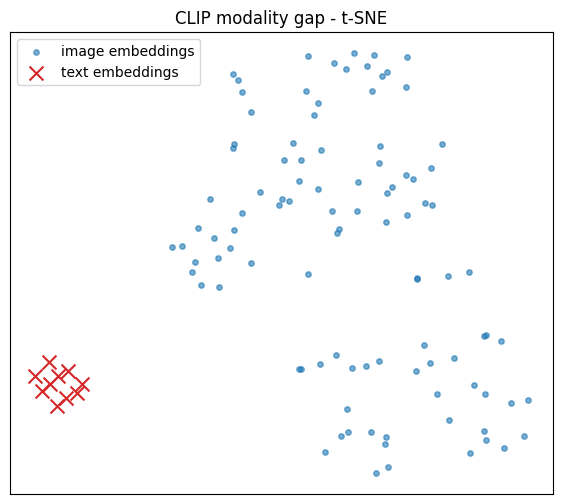

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


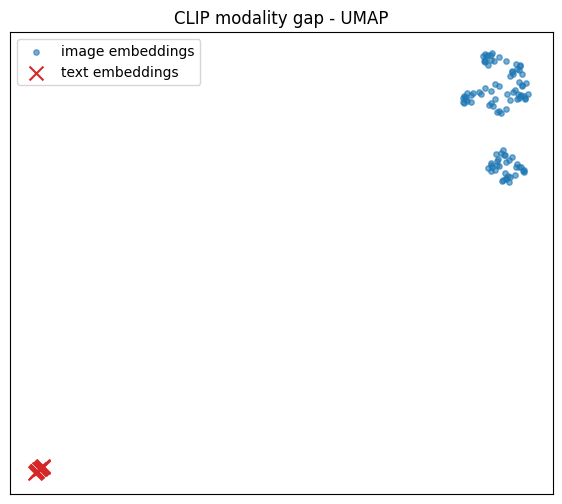

In [25]:
combined = np.vstack([img_embeds, txt_embeds])
modality_flag = np.array(["image"]*len(img_embeds) + ["text"]*len(txt_embeds))

tsne_emb = TSNE(n_components=2, random_state=42, init="pca", perplexity=30).fit_transform(combined)

plt.figure(figsize=(7,6))
img_mask = modality_flag == "image"
txt_mask = modality_flag == "text"
plt.scatter(tsne_emb[img_mask,0], tsne_emb[img_mask,1], c="tab:blue", label="image embeddings", alpha=0.6, s=15)
plt.scatter(tsne_emb[txt_mask,0], tsne_emb[txt_mask,1], c="tab:red", label="text embeddings", marker="x", s=100)
plt.legend(); plt.title("CLIP modality gap - t-SNE"); plt.xticks([]); plt.yticks([])
plt.savefig("modality_gap_tsne.png", dpi=150)
plt.show()

umap_emb = umap.UMAP(n_components=2, random_state=42).fit_transform(combined)
plt.figure(figsize=(7,6))
plt.scatter(umap_emb[img_mask,0], umap_emb[img_mask,1], c="tab:blue", label="image embeddings", alpha=0.6, s=15)
plt.scatter(umap_emb[txt_mask,0], umap_emb[txt_mask,1], c="tab:red", label="text embeddings", marker="x", s=100)
plt.legend(); plt.title("CLIP modality gap - UMAP"); plt.xticks([]); plt.yticks([])
plt.savefig("modality_gap_umap.png", dpi=150)
plt.show()

Pair each image with the text embedding of its true class to quantify cross-modal alignment more precisely.

In [26]:
@torch.no_grad()
def collect_paired_embeddings(model, dataset, class_names, n_samples=200):
    """Each image is paired with the TEXT embedding of its OWN true class."""
    indices = random.sample(range(len(dataset)), n_samples)
    prompts = [f"a photo of a {c}" for c in class_names]
    text_tokens = clip.tokenize(prompts).to(device)
    text_features = model.encode_text(text_tokens)
    text_features = (text_features / text_features.norm(dim=-1, keepdim=True)).cpu().numpy()

    image_embeds, paired_text_embeds, labels = [], [], []
    for idx in indices:
        img, label = dataset[idx]
        img_features = model.encode_image(img.unsqueeze(0).to(device))
        img_features = img_features / img_features.norm(dim=-1, keepdim=True)
        image_embeds.append(img_features.cpu().numpy()[0])
        paired_text_embeds.append(text_features[label])  
        labels.append(label)

    return np.array(image_embeds), np.array(paired_text_embeds), np.array(labels), text_features

X_img, Y_txt_paired, pair_labels, all_text_features = collect_paired_embeddings(clip_model, stl_test, class_names, n_samples=200)
print("Paired image embeds:", X_img.shape, "| Paired text embeds:", Y_txt_paired.shape)

Paired image embeds: (200, 512) | Paired text embeds: (200, 512)


We apply orthogonal Procrustes alignment to rotate image embeddings toward the text embedding space, testing whether this closes the modality gap.

Rotation matrix shape: (512, 512)


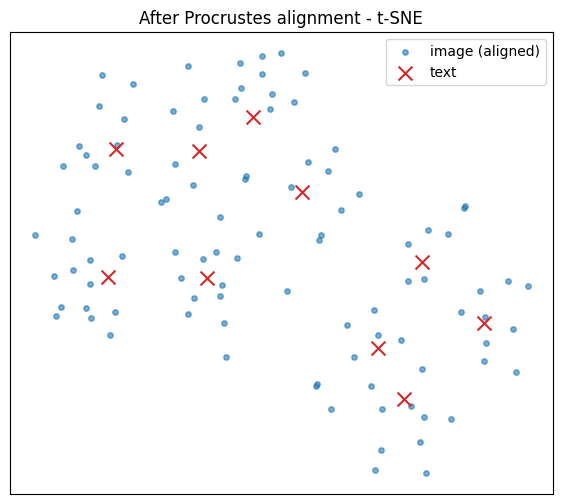

In [27]:
from scipy.linalg import orthogonal_procrustes

R, scale = orthogonal_procrustes(X_img, Y_txt_paired)
print("Rotation matrix shape:", R.shape)

X_img_aligned = img_embeds @ R  

combined_aligned = np.vstack([X_img_aligned, txt_embeds])
tsne_aligned = TSNE(n_components=2, random_state=42, init="pca", perplexity=30).fit_transform(combined_aligned)

plt.figure(figsize=(7,6))
plt.scatter(tsne_aligned[img_mask,0], tsne_aligned[img_mask,1], c="tab:blue", label="image (aligned)", alpha=0.6, s=15)
plt.scatter(tsne_aligned[txt_mask,0], tsne_aligned[txt_mask,1], c="tab:red", label="text", marker="x", s=100)
plt.legend(); plt.title("After Procrustes alignment - t-SNE"); plt.xticks([]); plt.yticks([])
plt.savefig("modality_gap_aligned_tsne.png", dpi=150)
plt.show()

We re-evaluate zero-shot accuracy after Procrustes alignment to check whether closing the modality gap improves classification.

In [28]:
@torch.no_grad()
def zero_shot_accuracy_aligned(model, loader, class_names, R):
    """Compute zero-shot accuracy using image embeddings rotated by Procrustes matrix R."""
    prompts = [f"a photo of a {c}" for c in class_names]
    text_tokens = clip.tokenize(prompts).to(device)
    text_features = model.encode_text(text_tokens)
    text_features = (text_features / text_features.norm(dim=-1, keepdim=True)).cpu().numpy()

    correct, total = 0, 0
    for images, labels in loader:
        images = images.to(device)
        image_features = model.encode_image(images)
        image_features = (image_features / image_features.norm(dim=-1, keepdim=True)).cpu().numpy()

        image_features_aligned = image_features @ R
        similarity = image_features_aligned @ text_features.T
        preds = similarity.argmax(axis=-1)
        correct += (preds == labels.numpy()).sum()
        total += labels.size(0)
    return correct / total

aligned_acc = zero_shot_accuracy_aligned(clip_model, stl_loader, class_names, R)
print(f"Zero-shot accuracy BEFORE alignment (photo_of prompt): {zero_shot_results['photo_of']:.4f}")
print(f"Zero-shot accuracy AFTER Procrustes alignment:          {aligned_acc:.4f}")

Zero-shot accuracy BEFORE alignment (photo_of prompt): 0.9736
Zero-shot accuracy AFTER Procrustes alignment:          0.9744


**Summary of Task 3 Results**

In [29]:
print("=== Task 3 Summary ===")
print("\nZero-shot accuracy by prompting strategy:")
for name, acc in zero_shot_results.items():
    print(f"  {name}: {acc:.4f}")
print(f"\nAfter Procrustes alignment: {aligned_acc:.4f}")

=== Task 3 Summary ===

Zero-shot accuracy by prompting strategy:
  plain_label: 0.9626
  photo_of: 0.9736
  descriptive: 0.9594

After Procrustes alignment: 0.9744


## Task 4: Variational Autoencoders (VAE)

We implement a VAE trained on MNIST, examine its 2D latent space structure, inspect reconstructions, and generate new samples from the prior.

We set up MNIST data loaders, which we use to train the VAE below.

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = transforms.ToTensor()  

train_set = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_set  = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_set, batch_size=128, shuffle=False)

print(f"Train: {len(train_set)}, Test: {len(test_set)}")

Device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 32.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.01MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.33MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.39MB/s]

Train: 60000, Test: 10000


We define the VAE architecture: an encoder producing a latent mean/log-variance, the reparameterization trick, and a decoder reconstructing the input.

In [31]:
LATENT_DIM = 2 

class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=400):
        super().__init__()
        self.enc_fc1 = nn.Linear(784, hidden_dim)
        self.enc_mu = nn.Linear(hidden_dim, latent_dim)
        self.enc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.dec_fc1 = nn.Linear(latent_dim, hidden_dim)
        self.dec_out = nn.Linear(hidden_dim, 784)

    def encode(self, x):
        h = F.relu(self.enc_fc1(x))
        mu = self.enc_mu(h)
        logvar = self.enc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)          
        eps = torch.randn_like(std)             
        return mu + std * eps                   

    def decode(self, z):
        h = F.relu(self.dec_fc1(z))           
        logits = self.dec_out(h)               
        return logits

    def forward(self, x):
        x_flat = x.view(x.size(0), -1)         
        mu, logvar = self.encode(x_flat)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z)
        return logits, mu, logvar


def vae_loss(logits, x, mu, logvar):
    x_flat = x.view(x.size(0), -1)
    recon_loss = F.binary_cross_entropy_with_logits(logits, x_flat, reduction="sum")

    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss, recon_loss, kl_loss

We train the VAE, tracking total loss, reconstruction loss, and KL-divergence loss per epoch.

In [ ]:
model = VAE(latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_epoch():
    model.train()
    total_loss, total_recon, total_kl = 0, 0, 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        logits, mu, logvar = model(x)
        loss, recon, kl = vae_loss(logits, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()
    n = len(train_loader.dataset)
    return total_loss/n, total_recon/n, total_kl/n

@torch.no_grad()
def eval_epoch():
    model.eval()
    total_loss = 0
    for x, _ in test_loader:
        x = x.to(device)
        logits, mu, logvar = model(x)
        loss, _, _ = vae_loss(logits, x, mu, logvar)
        total_loss += loss.item()
    return total_loss / len(test_loader.dataset)

EPOCHS = 15
history = {"train_loss": [], "train_recon": [], "train_kl": [], "test_loss": []}
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_recon, tr_kl = train_epoch()
    te_loss = eval_epoch()
    history["train_loss"].append(tr_loss)
    history["train_recon"].append(tr_recon)
    history["train_kl"].append(tr_kl)
    history["test_loss"].append(te_loss)
    print(f"Epoch {epoch}/{EPOCHS} | train_loss={tr_loss:.2f} (recon={tr_recon:.2f}, kl={tr_kl:.2f}) | test_loss={te_loss:.2f}")

We plot the VAE's training and test ELBO loss curves.

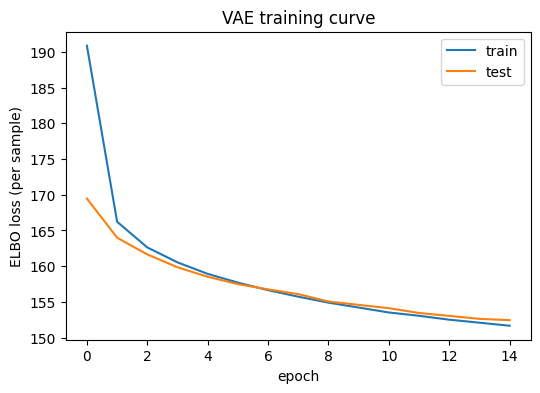

In [33]:
plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["test_loss"], label="test")
plt.xlabel("epoch"); plt.ylabel("ELBO loss (per sample)"); plt.legend()
plt.title("VAE training curve")
plt.savefig("vae_loss_curve.png", dpi=150)
plt.show()

We project test-set inputs to their latent means and visualize the resulting 2D latent space, colored by digit class.

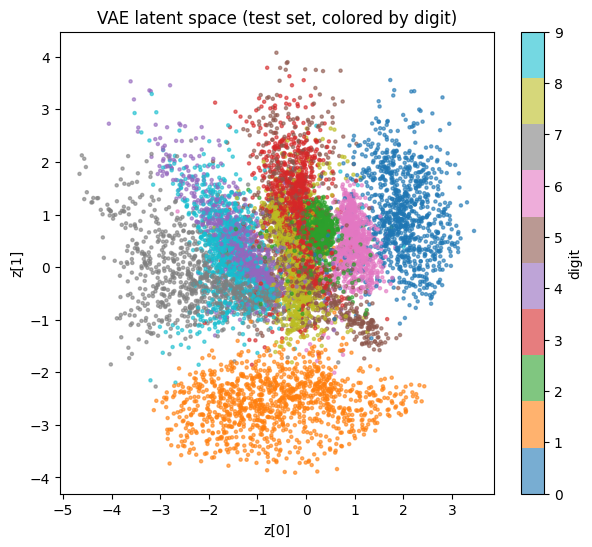

In [34]:
@torch.no_grad()
def get_latent_means(model, loader):
    model.eval()
    all_mu, all_labels = [], []
    for x, y in loader:
        x = x.to(device)
        mu, _ = model.encode(x.view(x.size(0), -1))
        all_mu.append(mu.cpu())
        all_labels.append(y)
    return torch.cat(all_mu).numpy(), torch.cat(all_labels).numpy()

test_mu, test_labels = get_latent_means(model, test_loader)

plt.figure(figsize=(7,6))
scatter = plt.scatter(test_mu[:,0], test_mu[:,1], c=test_labels, cmap="tab10", s=5, alpha=0.6)
plt.colorbar(scatter, ticks=range(10), label="digit")
plt.title("VAE latent space (test set, colored by digit)")
plt.xlabel("z[0]"); plt.ylabel("z[1]")
plt.savefig("vae_latent_space.png", dpi=150)
plt.show()

We visually compare original MNIST digits to their VAE reconstructions.

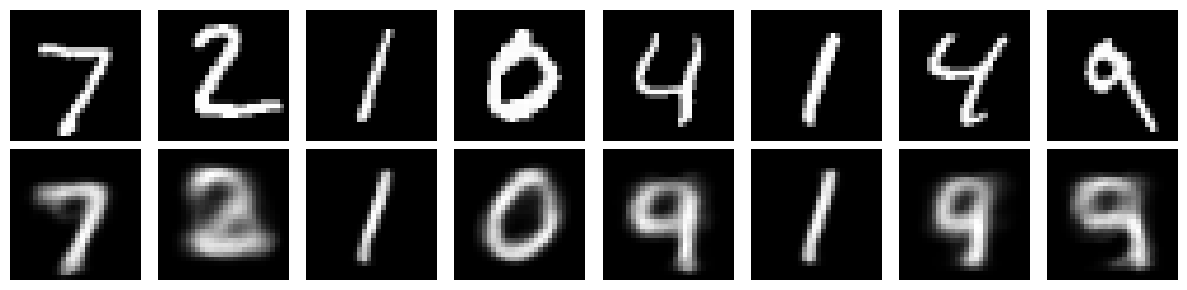

In [35]:
@torch.no_grad()
def show_reconstructions(model, loader, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)
    logits, mu, logvar = model(x)
    recon = torch.sigmoid(logits).view(-1, 1, 28, 28)  

    fig, axes = plt.subplots(2, n, figsize=(n*1.5, 3))
    for i in range(n):
        axes[0,i].imshow(x[i,0].cpu(), cmap="gray"); axes[0,i].axis("off")
        axes[1,i].imshow(recon[i,0].cpu(), cmap="gray"); axes[1,i].axis("off")
    axes[0,0].set_ylabel("original", rotation=0, labelpad=40, fontsize=10)
    axes[1,0].set_ylabel("reconstructed", rotation=0, labelpad=40, fontsize=10)
    plt.tight_layout()
    plt.savefig("vae_reconstructions.png", dpi=150)
    plt.show()

show_reconstructions(model, test_loader, n=8)

We sample from the prior and decode to generate new, previously unseen digit images.

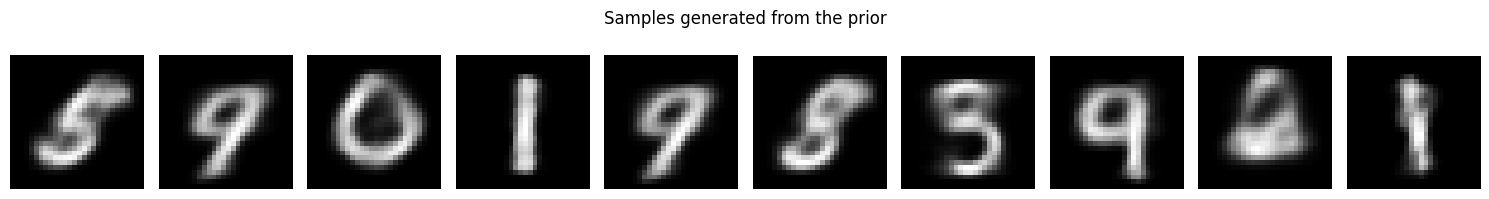

In [36]:
@torch.no_grad()
def generate_samples(model, n=10, latent_dim=LATENT_DIM):
    model.eval()
    z = torch.randn(n, latent_dim).to(device)   
    logits = model.decode(z)
    samples = torch.sigmoid(logits).view(-1, 1, 28, 28)

    fig, axes = plt.subplots(1, n, figsize=(n*1.5, 2))
    for i in range(n):
        axes[i].imshow(samples[i,0].cpu(), cmap="gray"); axes[i].axis("off")
    plt.suptitle("Samples generated from the prior")
    plt.tight_layout()
    plt.savefig("vae_generated_samples.png", dpi=150)
    plt.show()

generate_samples(model, n=10)

## Overall Conclusion

Across Tasks 1–4 we examined how depth, attention, cross-modal alignment, and generative latent structure each shape representation learning: residual connections were shown to be essential to trainability at depth, ViT attention concentrates on semantically relevant patches, CLIP's zero-shot accuracy improves after closing the image/text modality gap, and the VAE learns a smooth, structured latent space supporting both reconstruction and generation.